# Case Study - CRC (SRM colorectal cancer data)

This is case study using the experimental data from [Surinova et al. (2015)](https://pmc.ncbi.nlm.nih.gov/articles/PMC4568950/).

The dataset is available at: TODO (data is impossible to get online. Need to post the MSstats copy somewhere)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D
import networkx as nx
import matplotlib.pyplot as plt

import matplotlib
from matplotlib.collections import LineCollection
from scipy.stats import gaussian_kde

import json
import scipy
import scipy.cluster.hierarchy as sch
import sys
import os
current_dir = os.getcwd()
sys.path.append(os.path.join(os.path.dirname(current_dir), 'code'))
import pickle

import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from protmapper import uniprot_client
from indra.databases import hgnc_client

from MSquantSim.simulate import simulate_using_copula, simulate_using_tvae, \
    simulate_using_per_protein
from MSquantSim.downstreamanalysis import run_random_forest
from MSquantSim.similarity_scores import plot_corr, similarity_across_simulations

from causomic.graph_construction.utils import get_neighbor_network
from causomic.graph_construction.indra_queries import get_ids, format_query_results
from sklearn.impute import KNNImputer

import warnings
warnings.filterwarnings('ignore')

import os
from indra_cogex.client import Neo4jClient

client = Neo4jClient(url=os.getenv("API_URL"), 
                        auth=(os.getenv("USER"), 
                            os.getenv("PASSWORD"))
                    )

def hgnc_converter(id, mnemonic_id=False):
    if mnemonic_id:
        uniprot_id = uniprot_client.get_id_from_mnemonic(id)
    else:
        uniprot_id = id
    hgnc_id = uniprot_client.get_hgnc_id(uniprot_id)
    hgnc_name = hgnc_client.get_hgnc_name(hgnc_id)
    return hgnc_name

/Users/kohler.d/miniconda3/envs/MSquantSim_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


IPython not installed.


INFO: [2026-01-08 09:17:33] indra_cogex.client.neo4j_client - Connected to neo4j graph at bolt://indra-cogex-lb-b954b684556c373c.elb.us-east-1.amazonaws.com:7687


Plasma samples were subjected to parallel N-glycoprotein
extraction in a 96-well format, followed by targeted Selected Reaction Monitoring (SRM)
quantification of 67 candidate proteins by SRM. PSMs were summarized into protein-level
summaries by MSstatsTMT. 

## Process MSstats protein-level data

In [2]:
crc_input = pd.read_csv('../data/CRC/CRC_training_protein_level_data.csv')
crc_validation_input = pd.read_csv('../data/CRC/CRC_validation_protein_level_data.csv')
crc_input.head()

,Run,A1AG2,AFM,AHSG,ANT3,AOC3,APOB,ATRN,BTD,C20orf3,...,SERPINA1,SERPINA3,SERPINA6,SERPINA7,THBS1,TIMP1,VTN,VWF,Condition,BioReplicate
0,CRC_P1A10,14.238157,16.103019,19.951792,17.207936,10.032169,15.544774,14.383388,16.283071,10.667779,...,18.061091,14.218036,15.796849,13.581848,13.995686,11.578754,12.081352,10.661031,CRC,CRC_P1A10
1,CRC_P1A2,15.024111,16.020714,19.715919,17.297900,9.034144,15.131883,13.981723,16.249189,10.703279,...,17.610188,14.832327,15.815397,13.138445,13.707714,11.960974,12.838407,10.778432,CRC,CRC_P1A2
2,CRC_P1A4,15.631364,16.143800,19.710849,17.596254,10.381880,15.955302,14.635355,16.499158,11.183873,...,18.539972,15.308726,16.401770,13.742330,15.636962,12.155842,12.313155,11.185271,CRC,CRC_P1A4
3,CRC_P1A6,15.401365,16.276415,19.704377,17.422504,9.502960,15.714932,14.060700,16.277732,9.972982,...,17.401414,14.254241,16.310491,13.936894,15.517268,12.379265,10.679166,10.887855,CRC,CRC_P1A6
4,CRC_P1B12,16.003158,16.958207,20.420334,17.988199,9.648502,16.247330,14.203595,16.541422,12.581556,...,17.448008,16.231911,16.485833,14.167134,15.129106,12.169116,14.506106,11.254175,CRC,CRC_P1B12


In [4]:
# Split into health and disease
crc_healthy = crc_input[crc_input['Condition'] == 'Healthy'].drop(columns=['Condition', 'Run', 'BioReplicate'])
crc_disease = crc_input[crc_input['Condition'] == 'CRC'].drop(columns=['Condition', 'Run', 'BioReplicate'])

## Simulations
### Copula
#### Single simulation

In [4]:
copula_sim_healthy = simulate_using_copula(
    crc_healthy, num_simulations=1, 
    samples_per_simulation=len(crc_healthy), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

copula_sim_disease = simulate_using_copula(
    crc_disease, num_simulations=1, 
    samples_per_simulation=len(crc_disease), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

INFO: [2025-12-22 09:24:05] copulas.multivariate.gaussian - Fitting GaussianMultivariate()
INFO: [2025-12-22 09:24:14] copulas.multivariate.gaussian - Fitting GaussianMultivariate()


#### Multiple simulations

In [5]:
n_sims = 100

copula_sim_crc_healthy_multi = simulate_using_copula(
    crc_healthy, num_simulations=n_sims, 
    samples_per_simulation=len(crc_healthy), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

copula_sim_crc_disease_multi = simulate_using_copula(
    crc_disease, num_simulations=n_sims, 
    samples_per_simulation=len(crc_disease), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

Running copula simulations: 100%|██████████| 100/100 [01:58<00:00,  1.19s/it]


In [6]:
with open("../../data/CRC_data/results/COPULA_CRC_healthy.pkl", "wb") as f:
    pickle.dump(copula_sim_crc_healthy_multi, f)
with open("../../data/CRC_data/results/COPULA_CRC_disease.pkl", "wb") as f:
    pickle.dump(copula_sim_crc_disease_multi, f)

### TVAE

#### Single simulation

In [ ]:
tvae_sim_healthy = simulate_using_tvae(
    crc_healthy, None, num_simulations=1,
    samples_per_simulation=len(crc_healthy), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

tvae_sim_disease = simulate_using_tvae(
    crc_disease, None, num_simulations=1,
    samples_per_simulation=len(crc_disease), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

#### Multiple simulations

In [ ]:
n_sims = 100

tvae_sim_crc_healthy_multi = simulate_using_tvae(
    crc_healthy, None, num_simulations=n_sims,
    samples_per_simulation=len(crc_healthy), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

tvae_sim_crc_disease_multi = simulate_using_tvae(
    crc_disease, None, num_simulations=n_sims,
    samples_per_simulation=len(crc_disease), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

In [9]:
with open("../../data/CRC_data/results/TVAE_CRC_healthy.pkl", "wb") as f:
    pickle.dump(tvae_sim_crc_healthy_multi, f)
with open("../../data/CRC_data/results/TVAE_CRC_disease.pkl", "wb") as f:
    pickle.dump(tvae_sim_crc_disease_multi, f)

### Per-protein

#### Single simulation

In [10]:
pprotein_sim_healthy = simulate_using_per_protein(
    crc_healthy, num_simulations=1,
    samples_per_simulation=len(crc_healthy), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

pprotein_sim_disease = simulate_using_per_protein(
    crc_disease, num_simulations=1,
    samples_per_simulation=len(crc_disease), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

#### Multiple simulations

In [11]:
n_sims = 100

pprotein_sim_crc_healthy_multi = simulate_using_per_protein(
    crc_healthy, num_simulations=n_sims,
    samples_per_simulation=len(crc_healthy), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

pprotein_sim_crc_disease_multi = simulate_using_per_protein(
    crc_disease, num_simulations=n_sims,
    samples_per_simulation=len(crc_disease), # Set to size of input data to mirror variability
    output_dir=None, output_prefix='simulated',
    return_data=True, random_state=2
)

Running per-protein simulations: 100%|██████████| 100/100 [00:00<00:00, 1341.01it/s]


In [12]:
with open("../../data/CRC_data/results/PPROTEIN_CRC_healthy.pkl", "wb") as f:
    pickle.dump(pprotein_sim_crc_healthy_multi, f)
with open("../../data/CRC_data/results/PPROTEIN_CRC_disease.pkl", "wb") as f:
    pickle.dump(pprotein_sim_crc_disease_multi, f)

### Get pilot/historical data from past similar experiment

In [2]:
data = pd.read_csv('../casestudy/crc/data/crc_silvia_data.csv')
data.head()

,A1AG2,AFM,AHSG,ANT3,AOC3,APOB,ATRN,BTD,C20orf3,CADM1,...,Q5JNX2,SERPINA1,SERPINA3,SERPINA6,SERPINA7,THBS1,TIMP1,VTN,VWF,Condition
0,14.238157,16.103019,19.951792,17.207936,10.032169,15.544774,14.383388,16.283071,10.667779,9.653029,...,19.028130,18.061091,14.218036,15.796849,13.581848,13.995686,11.578754,12.081352,10.661031,CRC
1,15.024111,16.020714,19.715919,17.297900,9.034144,15.131883,13.981723,16.249189,10.703279,9.624991,...,19.862536,17.610188,14.832327,15.815397,13.138445,13.707714,11.960974,12.838407,10.778432,CRC
2,15.631364,16.143800,19.710849,17.596254,10.381880,15.955302,14.635355,16.499158,11.183873,10.323191,...,19.501773,18.539972,15.308726,16.401770,13.742330,15.636962,12.155842,12.313155,11.185271,CRC
3,15.401365,16.276415,19.704377,17.422504,9.502960,15.714932,14.060700,16.277732,9.972982,9.994209,...,19.984664,17.401414,14.254241,16.310491,13.936894,15.517268,12.379265,10.679166,10.887855,CRC
4,16.003158,16.958207,20.420334,17.988199,9.648502,16.247330,14.203595,16.541422,12.581556,9.607492,...,20.467453,17.448008,16.231911,16.485833,14.167134,15.129106,12.169116,14.506106,11.254175,CRC


## Evaluate simulations

In [5]:
with open("../../data/CRC_data/results/COPULA_CRC_healthy.pkl", "rb") as f:
    copula_sim_crc_healthy_multi = pickle.load(f)
with open("../../data/CRC_data/results/COPULA_CRC_disease.pkl", "rb") as f:
    copula_sim_crc_disease_multi = pickle.load(f)
with open("../../data/CRC_data/results/TVAE_CRC_healthy.pkl", "rb") as f:
    tvae_sim_crc_healthy_multi = pickle.load(f)
with open("../../data/CRC_data/results/TVAE_CRC_disease.pkl", "rb") as f:
    tvae_sim_crc_disease_multi = pickle.load(f)
with open("../../data/CRC_data/results/PPROTEIN_CRC_healthy.pkl", "rb") as f:
    pprotein_sim_crc_healthy_multi = pickle.load(f)
with open("../../data/CRC_data/results/PPROTEIN_CRC_disease.pkl", "rb") as f:
    pprotein_sim_crc_disease_multi = pickle.load(f)

### Correlation Heatmaps

#### Experimental data

In [16]:
def plot_corr(
    df: pd.DataFrame,
    size: float = 10,
    method: str = "pearson",
    cmap: str = "RdBu_r",
):
    """
    Professional, label-free correlation heatmap (lower triangle),
    optimized for large feature sets and colorblind safety.
    """
    # Keep numeric columns only
    x = df.select_dtypes(include=[np.number])
    if x.shape[1] < 2:
        raise ValueError("Need at least 2 numeric columns.")

    corr = x.corr(method=method)

    # Mask upper triangle + diagonal
    mask = np.triu(np.ones_like(corr, dtype=bool))
    corr_plot = corr.mask(mask)

    fig, ax = plt.subplots(figsize=(size, size), dpi=150)

    im = ax.imshow(
        corr_plot.to_numpy(),
        vmin=-1,
        vmax=1,
        cmap=cmap,
        interpolation="nearest",
    )

    # Remove all ticks and labels
    ax.set_xticks([])
    ax.set_yticks([])

    # Optional subtle grid for structure (can remove if you want ultra-clean)
    n = corr.shape[0]
    ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax.grid(which="minor", linewidth=0.4, alpha=.2)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
    cbar.ax.tick_params(labelsize=10)
    cbar.set_label("Correlation", fontsize=11)

    fig.tight_layout()
    return fig, ax

(<Figure size 750x750 with 2 Axes>, <Axes: >)

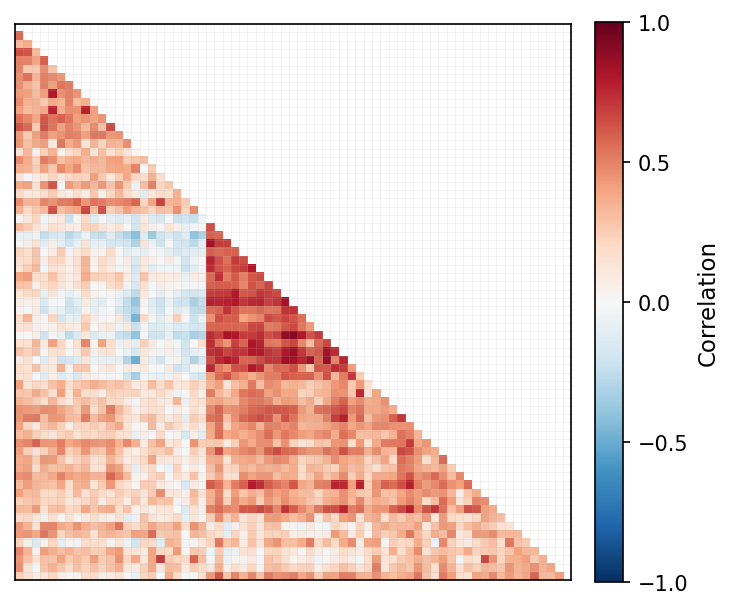

In [17]:
X = crc_healthy.corr().values
X[np.isnan(X)]= 0
d = sch.distance.pdist(X)   
L = sch.linkage(d, method='complete')
ind = sch.fcluster(L, 0.5*d.max(), 'distance')
columns = [crc_healthy.columns.tolist()[i] for i in list((np.argsort(ind)))]
crc_healthy = crc_healthy.reindex(columns, axis=1)
plot_corr(crc_healthy, size =5)

(<Figure size 750x750 with 2 Axes>, <Axes: >)

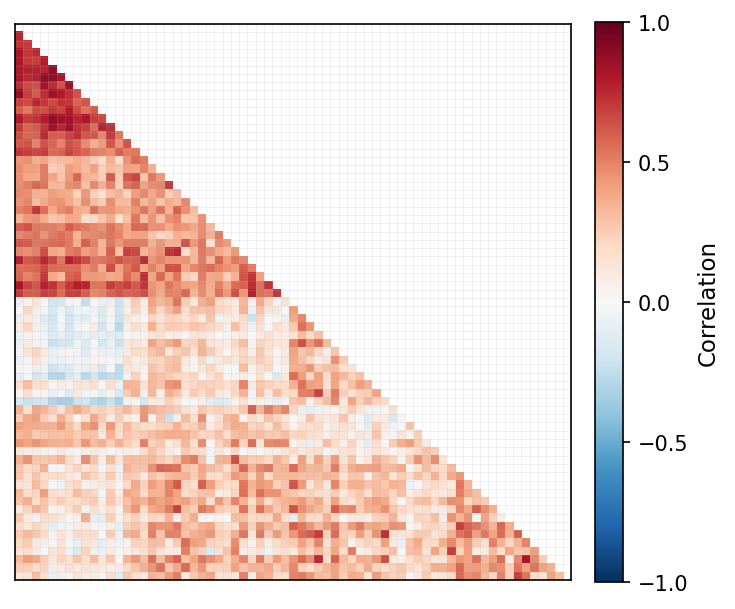

In [19]:
X = crc_disease.corr().values
X[np.isnan(X)]= 0
d = sch.distance.pdist(X)   
L = sch.linkage(d, method='complete')
ind = sch.fcluster(L, 0.5*d.max(), 'distance')
columns = [crc_disease.columns.tolist()[i] for i in list((np.argsort(ind)))]
crc_disease = crc_disease.reindex(columns, axis=1)
plot_corr(crc_disease, size =5)

#### Per-protein

(<Figure size 750x750 with 2 Axes>, <Axes: >)

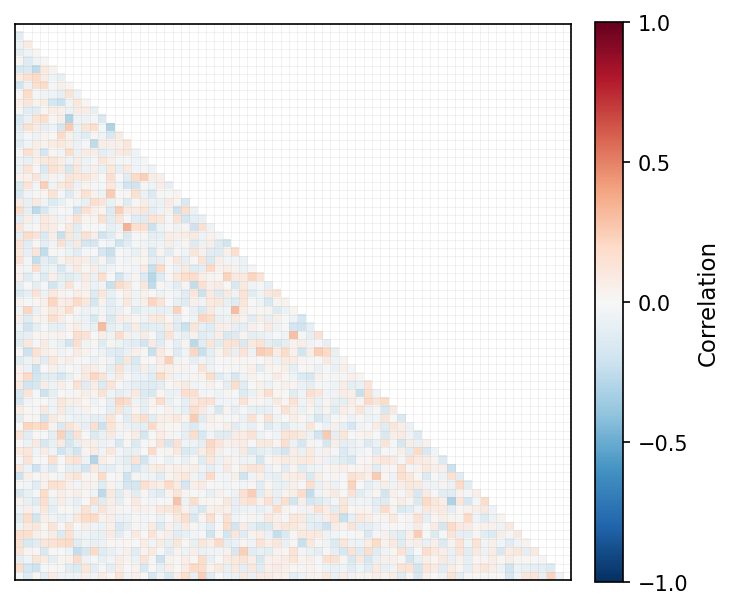

In [20]:
simpp0 = pprotein_sim_crc_healthy_multi[0]
simpp1 = pprotein_sim_crc_disease_multi[0]

simpp0 = simpp0.reindex(columns, axis=1)
plot_corr(simpp0, size = 5)

(<Figure size 750x750 with 2 Axes>, <Axes: >)

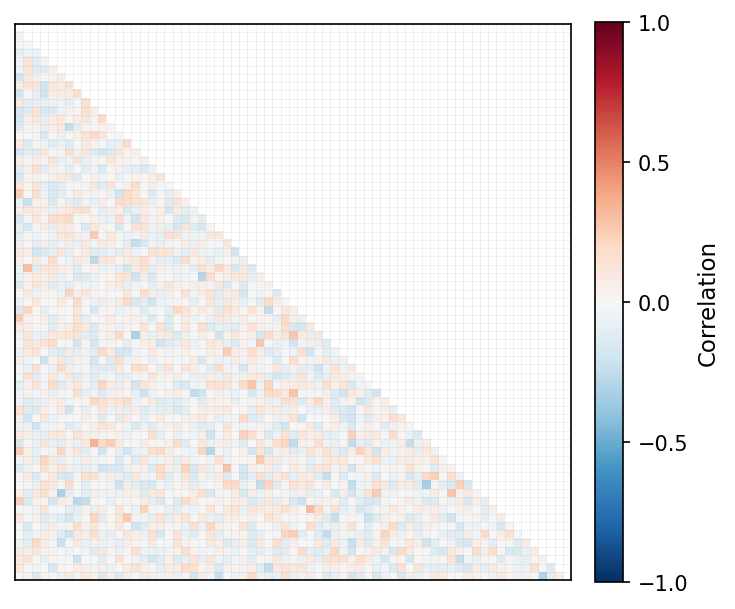

In [22]:
simpp1 = simpp1.reindex(columns, axis=1)
plot_corr(simpp1, size = 5)

#### VAE

(<Figure size 750x750 with 2 Axes>, <Axes: >)

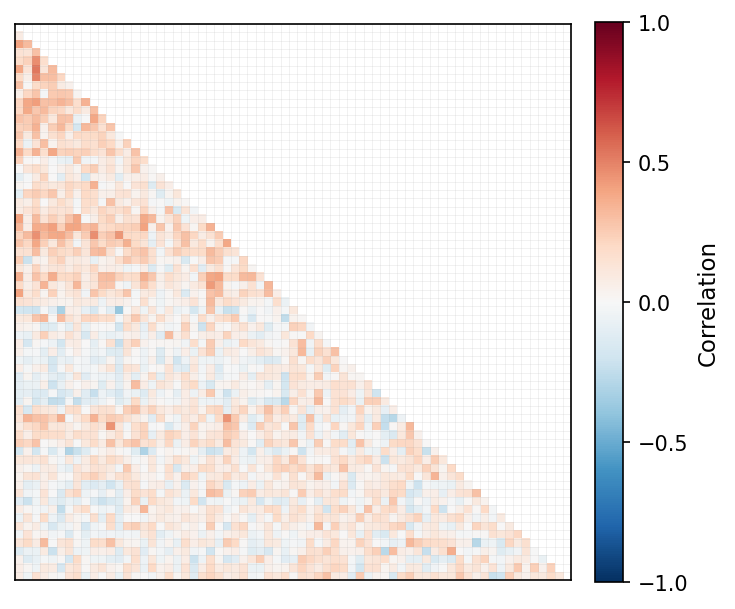

In [25]:
simtvae0 = tvae_sim_crc_healthy_multi[0]
simtvae1 = tvae_sim_crc_disease_multi[0]

simtvae0 = simtvae0.reindex(columns, axis=1)
plot_corr(simtvae0, size = 5)

(<Figure size 750x750 with 2 Axes>, <Axes: >)

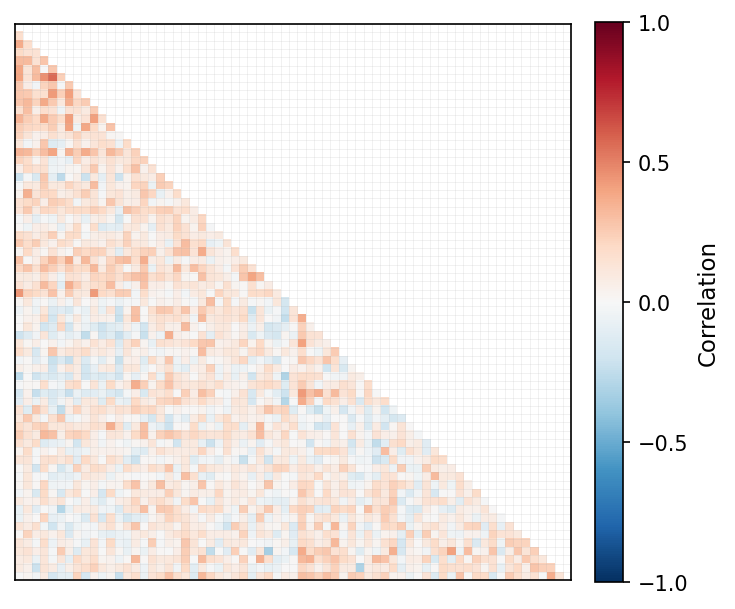

In [26]:
simtvae1 = simtvae1.reindex(columns, axis=1)
plot_corr(simtvae1, size = 5)

#### Copula

(<Figure size 750x750 with 2 Axes>, <Axes: >)

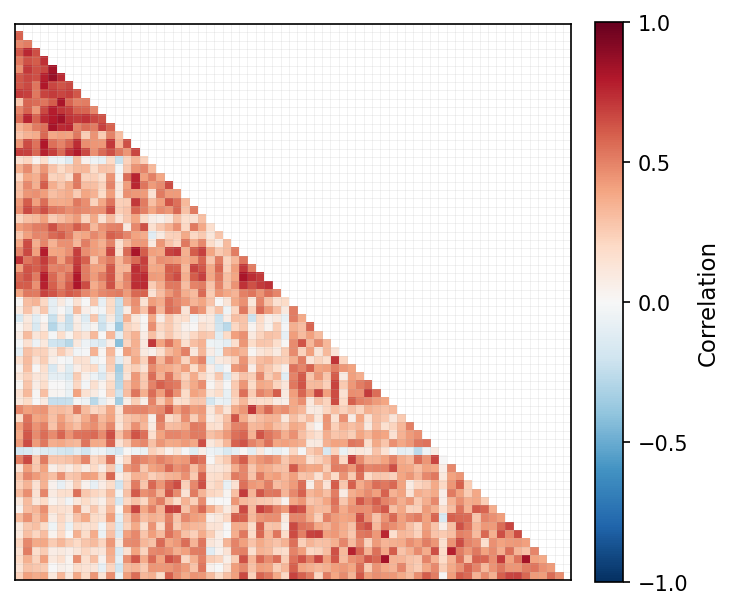

In [27]:
simco0 = copula_sim_crc_healthy_multi[0]
simco1 = copula_sim_crc_disease_multi[0]

simco0 = simco0.reindex(columns, axis=1)
plot_corr(simco0, size = 5)

(<Figure size 750x750 with 2 Axes>, <Axes: >)

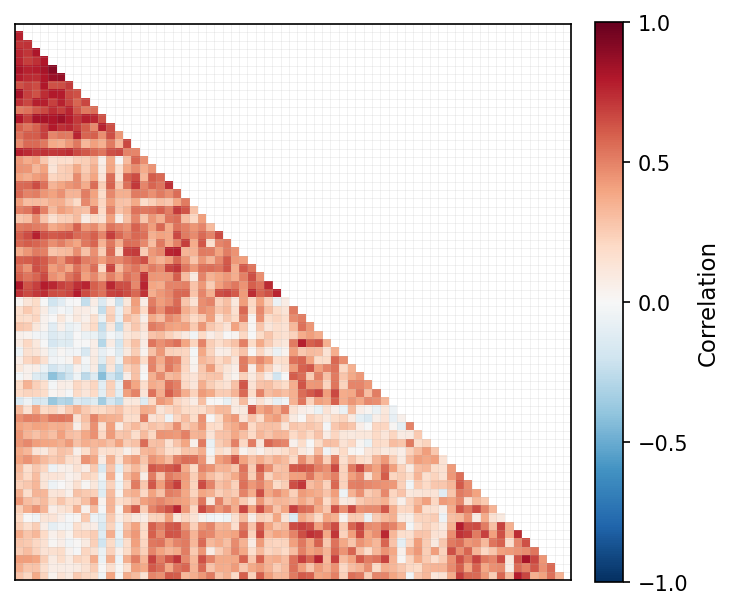

In [29]:
simco1 = simco1.reindex(columns, axis=1)
plot_corr(simco1, size = 5)

## Correlation statistics

In [10]:
crc_input = crc_input.drop(columns=['Run', 'BioReplicate'])

### Per-protein

In [ ]:
pp_sim_scores = similarity_across_simulations(pprotein_sim_crc_healthy_multi, 
                                              pprotein_sim_crc_disease_multi, 
                                              crc_input, "Condition", "Healthy", "CRC")

In [23]:
pp_avg_scores = {key: round(np.mean(values),4) for key, values in pp_sim_scores.items()}
print(pp_avg_scores.values())

dict_values([0.9986, -0.014, 0.9841, 0.8881, 0.7142])


In [27]:
pp_avg_scores = {key: round(np.std(values),4) for key, values in pp_sim_scores.items()}
print(pp_avg_scores.values())

dict_values([0.0003, 0.0209, 0.0007, 0.0379, 0.0113])


### TVAE

In [ ]:
tvae_sim_scores = similarity_across_simulations(tvae_sim_crc_healthy_multi, 
                                                tvae_sim_crc_disease_multi, 
                                                crc_input, "Condition", "Healthy", "CRC")

In [28]:
tvae_avg_scores = {key: round(np.mean(values),4) for key, values in tvae_sim_scores.items()}
print(tvae_avg_scores.values())

dict_values([0.9806, 0.4519, 0.9848, 0.8381, 0.8139])


In [29]:
tvae_avg_scores = {key: round(np.std(values),4) for key, values in tvae_sim_scores.items()}
print(tvae_avg_scores.values())

dict_values([0.0015, 0.0472, 0.0006, 0.0283, 0.0141])


### Copula

In [ ]:
copula_sim_scores = similarity_across_simulations(copula_sim_crc_healthy_multi, 
                                                  copula_sim_crc_disease_multi, 
                                                  crc_input, "Condition", "Healthy", "CRC")

In [30]:
copula_avg_scores = {key: round(np.mean(values),4) for key, values in copula_sim_scores.items()}
print(copula_avg_scores.values())

dict_values([0.9972, 0.955, 0.9859, 0.8781, 0.954])


In [31]:
copula_avg_scores = {key: round(np.std(values),4) for key, values in copula_sim_scores.items()}
print(copula_avg_scores.values())

dict_values([0.0012, 0.0061, 0.0032, 0.0321, 0.0081])


## Planning. Use simulations to plan future experiments


#### Visual Metrics

#### Pairplot Experimental data

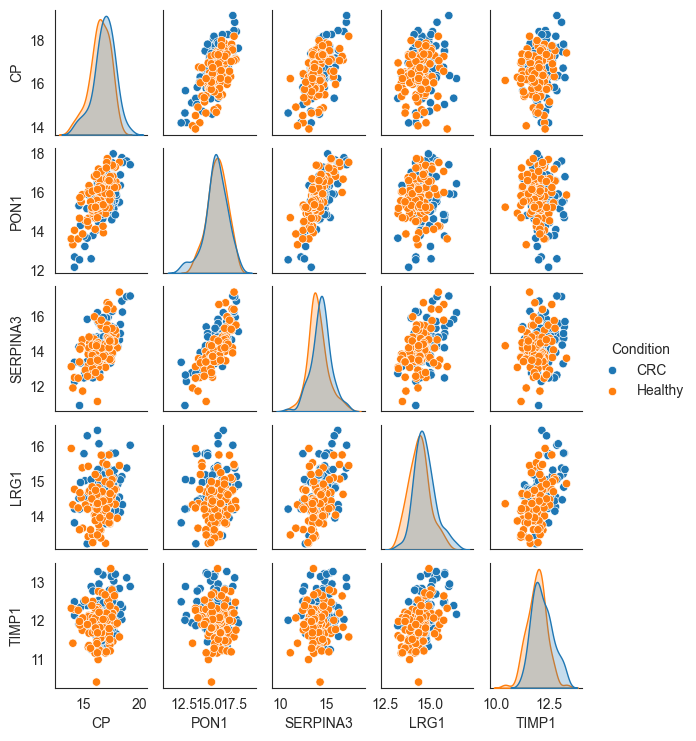

In [3]:
sns.set_style("white")
sns.pairplot(data[["CP","PON1","SERPINA3","LRG1","TIMP1","Condition"]], hue="Condition",height=1.5, aspect=0.8)

#### Pairplot Per-protein data

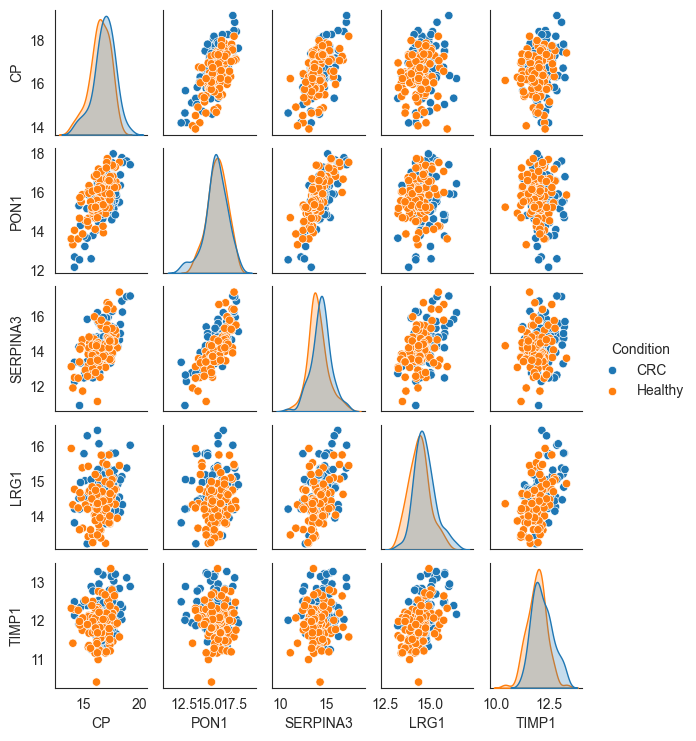

In [4]:
simpp0 = pd.read_csv('../casestudy/crc/perprotein/crc0_pp_0.csv')
simpp1 = pd.read_csv('../casestudy/crc/perprotein/crc1_pp_0.csv')
merged_df = pd.merge(simpp0, simpp1, how='outer', indicator=True)
merged_df['Condition'] = merged_df['_merge'].map({ 'left_only': 0, 'right_only': 1})
merged_df = merged_df.drop('_merge', axis=1)
sns.pairplot(data[["CP","PON1","SERPINA3","LRG1","TIMP1","Condition"]], hue="Condition",height=1.5, aspect=0.8)

#### Pairplot TVAE data

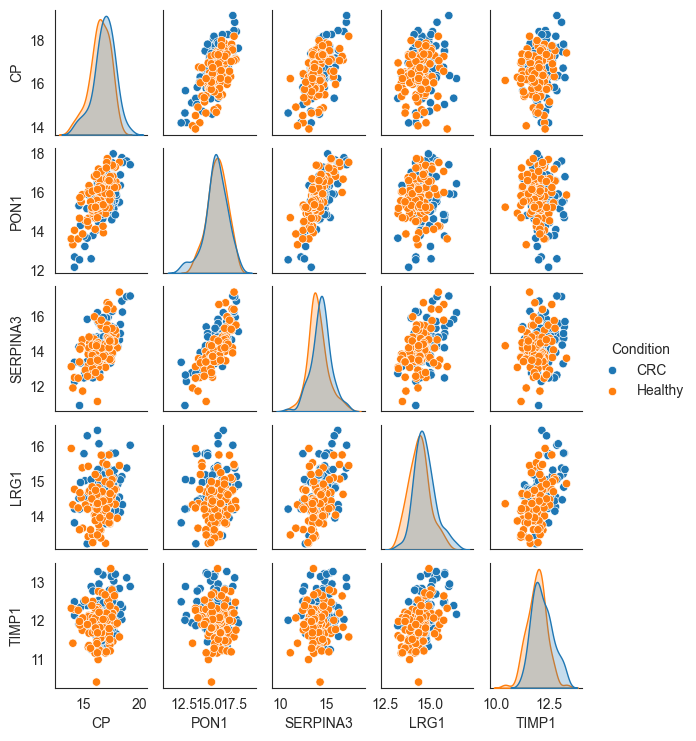

In [5]:
simtvae0 = pd.read_csv('../casestudy/crc/tvae/crc0_tvae_0.csv')
simtvae1 = pd.read_csv('../casestudy/crc/tvae/crc1_tvae_0.csv')
merged_df = pd.merge(simtvae0, simtvae1, how='outer', indicator=True)
merged_df['Condition'] = merged_df['_merge'].map({ 'left_only': 0, 'right_only': 1})
merged_df = merged_df.drop('_merge', axis=1)
sns.pairplot(data[["CP","PON1","SERPINA3","LRG1","TIMP1","Condition"]], hue="Condition",height=1.5, aspect=0.8)

#### Pairplot Copula data

In [11]:
df

,A1AG2,AFM,AHSG,ANT3,AOC3,APOB,ATRN,BTD,C20orf3,CADM1,...,PTPRJ,Q5JNX2,SERPINA1,SERPINA3,SERPINA6,SERPINA7,THBS1,TIMP1,VTN,VWF
100,14.522701,15.940212,20.084743,17.854882,9.265317,15.561483,13.277309,15.841669,11.378164,8.886986,...,9.974945,19.810557,16.734527,14.670002,15.903624,13.240460,14.429249,11.757719,12.961205,11.148027
101,15.294532,15.935520,19.784254,17.318508,9.731454,15.739329,14.558598,15.970486,10.837733,10.162198,...,10.224742,19.417183,19.055394,14.957223,16.638847,13.368402,14.804730,11.906788,12.124032,10.050453
102,14.317982,16.029300,19.826004,17.168676,10.719039,15.031820,13.823845,15.961511,10.878353,9.399227,...,9.369648,19.009737,18.014983,14.712584,15.778314,13.605648,14.881317,11.997252,11.696529,11.122208
103,14.743974,17.271903,20.546815,17.614134,10.425442,15.755704,13.894078,16.797642,12.043986,10.036943,...,10.386299,19.165669,17.274783,14.509578,16.018403,13.797991,16.307502,12.344813,13.262589,10.841750
104,14.473524,15.997162,19.822254,16.851331,9.359456,15.273471,13.823559,16.317857,11.503514,9.488784,...,10.332763,19.338430,17.778327,13.572941,15.541310,13.130568,15.023347,12.220879,12.233400,10.814681
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,14.442917,15.990122,18.665888,16.506105,9.325916,14.745428,13.072122,15.534248,10.767566,9.142328,...,10.116428,19.185454,16.173700,13.396709,14.815274,12.338600,15.691712,11.984285,11.879767,11.062184
196,15.116044,16.625768,19.475982,17.245004,9.258360,15.141649,13.424602,15.977121,9.889204,9.298522,...,10.051727,20.052715,16.286212,12.785561,15.497808,13.122072,13.001543,11.816094,12.012430,10.250246
197,15.041488,15.224106,18.525146,16.235877,9.284527,14.812296,13.922798,14.939264,10.622075,8.846313,...,9.538417,18.668108,17.149908,11.122248,15.228195,11.783661,13.346080,11.176881,12.438623,9.410451
198,13.922867,16.388432,19.199723,16.204601,9.089451,14.572485,12.838552,15.439934,9.883794,8.043888,...,9.652422,19.585959,15.788897,12.577409,14.677995,12.614804,14.596866,11.905893,10.916887,10.700179


(array([   0.,  200.,  400.,  600.,  800., 1000., 1200.]),
 [Text(0, 0.0, '0'),
  Text(0, 200.0, '200'),
  Text(0, 400.0, '400'),
  Text(0, 600.0, '600'),
  Text(0, 800.0, '800'),
  Text(0, 1000.0, '1000'),
  Text(0, 1200.0, '1200')])

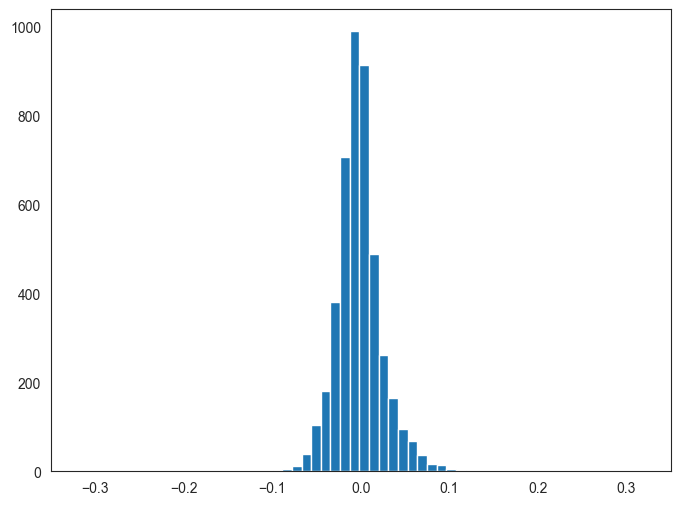

In [18]:
simco0 = pd.read_csv('../casestudy/crc/copula/test.csv')#crc0_gm_copula_0.csv')
df = data
df_with_0 = df[df['Condition'] == 'Healthy'].drop(columns='Condition')
df_with_1 = df[df['Condition'] == 'CRC'].drop(columns='Condition')
df = df_with_0

fig, ax = plt.subplots(figsize=(8,6))
ax.hist(pd.Series((df.corr() - simco0.corr()).values.flatten()), bins=20)
ax.set_xlim(-.35,.35)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

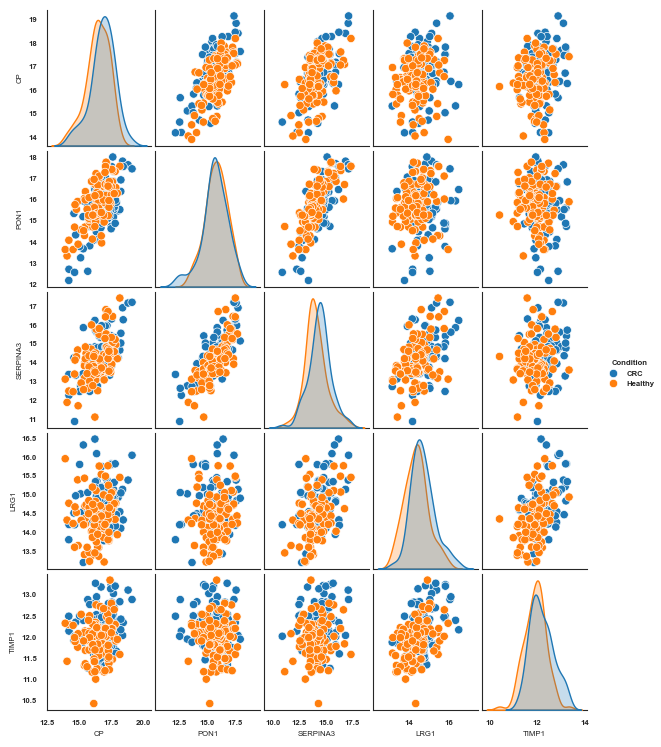

In [38]:
simco0 = pd.read_csv('../casestudy/crc/copula/test.csv')#crc0_gm_copula_0.csv')
simco1 = pd.read_csv('../casestudy/crc/copula/crc1_gm_copula_0.csv')
merged_df = pd.merge(simco0, simco1, how='outer', indicator=True)
merged_df['Condition'] = merged_df['_merge'].map({ 'left_only': 0, 'right_only': 1})
merged_df = merged_df.drop('_merge', axis=1)
sns.pairplot(data[["CP","PON1","SERPINA3","LRG1","TIMP1","Condition"]], hue="Condition",height=1.5, aspect=0.8)

#### Real correlation for Experimental healthy

In [ ]:
df = data
df_with_0 = df[df['Condition'] == 'Healthy'].drop(columns='Condition')
df_with_1 = df[df['Condition'] == 'CRC'].drop(columns='Condition')
df = df_with_0
X = df.corr().values
X[np.isnan(X)]= 0
d = sch.distance.pdist(X)   
L = sch.linkage(d, method='complete')
ind = sch.fcluster(L, 0.5*d.max(), 'distance')
columns = [df.columns.tolist()[i] for i in list((np.argsort(ind)))]
df = df.reindex(columns, axis=1)
plot_corr(df, size=10,font_scale=0.5)

#### Correlation for Per-protein healthy

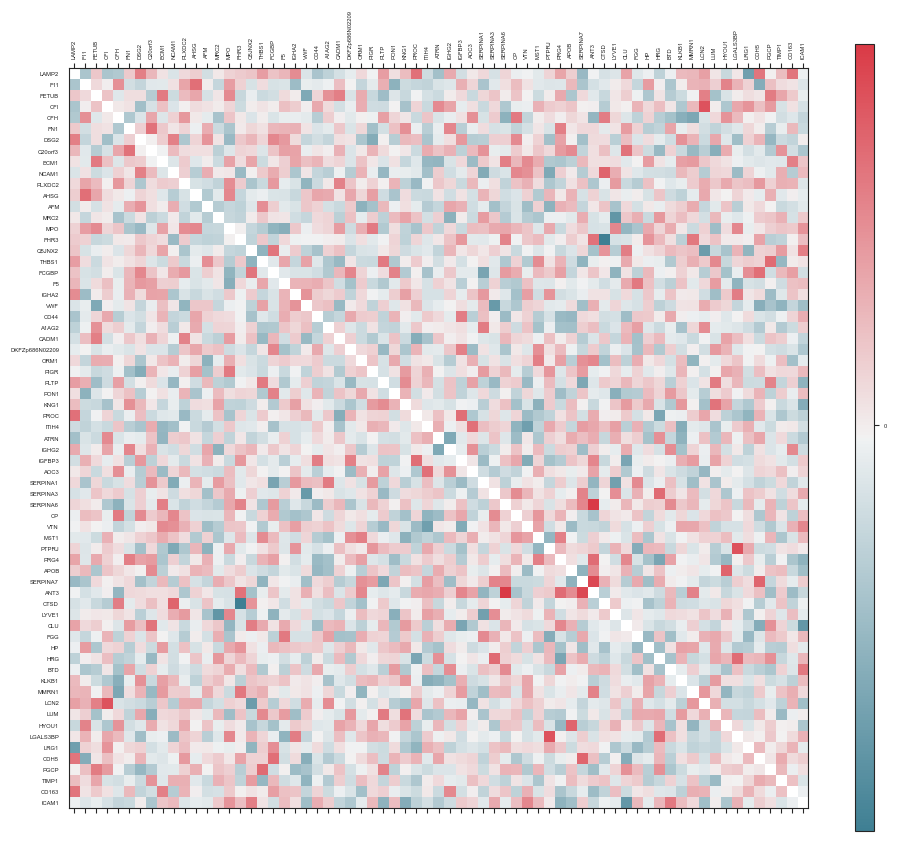

In [11]:
simpp0 = simpp0.reindex(columns, axis=1)
plot_corr(simpp0,size=10)

#### Correlation for TVAE healthy

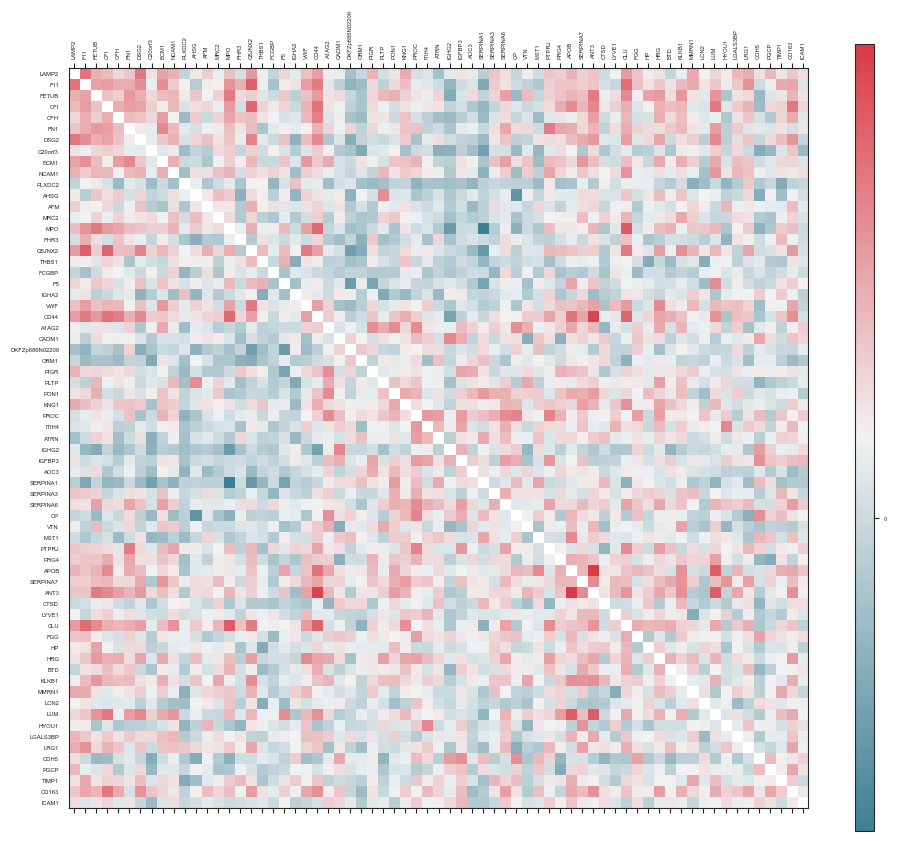

In [12]:
simtvae0 = simtvae0.reindex(columns, axis=1)
plot_corr(simtvae0,size=10)

#### Correlation for Copula healthy

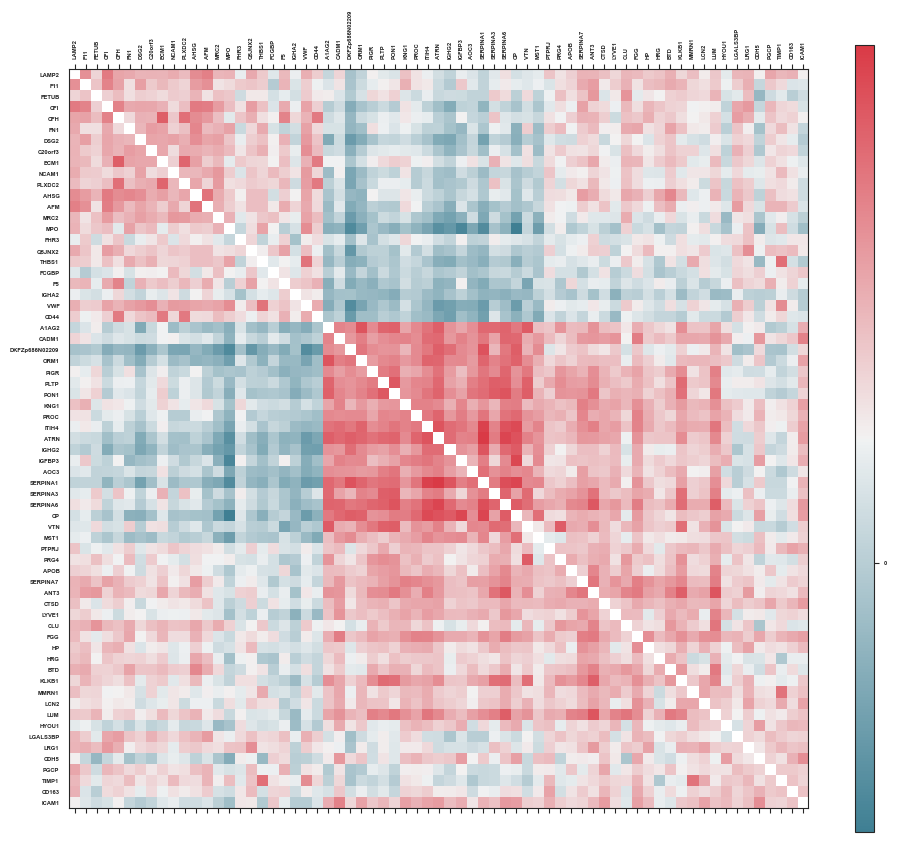

In [40]:
simco0 = simco0.reindex(columns, axis=1)
plot_corr(simco0,size=10)

#### Correlation for experimental data CRC

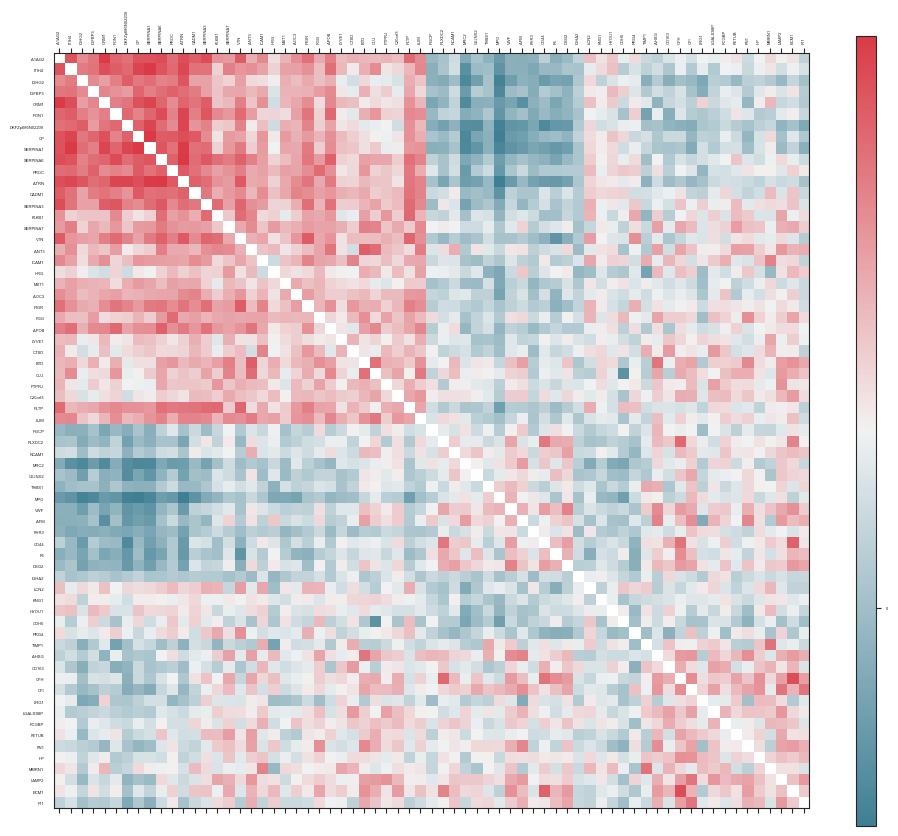

In [14]:
df = df_with_1
X = df.corr().values
X[np.isnan(X)]= 0
d = sch.distance.pdist(X)   
L = sch.linkage(d, method='complete')
ind = sch.fcluster(L, 0.5*d.max(), 'distance')
columns = [df.columns.tolist()[i] for i in list((np.argsort(ind)))]
df = df.reindex(columns, axis=1)
plot_corr(df, size=10,font_scale=0.5)

#### Correlation for Per-protein CRC

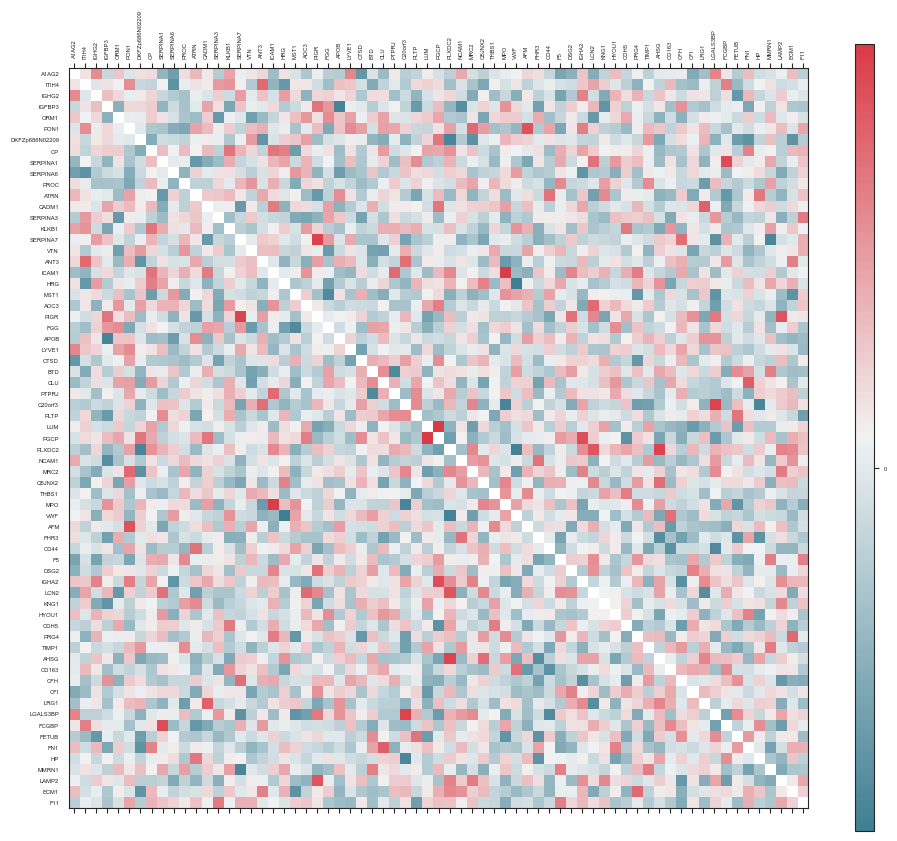

In [15]:
simpp1 = simpp1.reindex(columns, axis=1)
plot_corr(simpp1,size=10)

#### Correlation for TVAE CRC

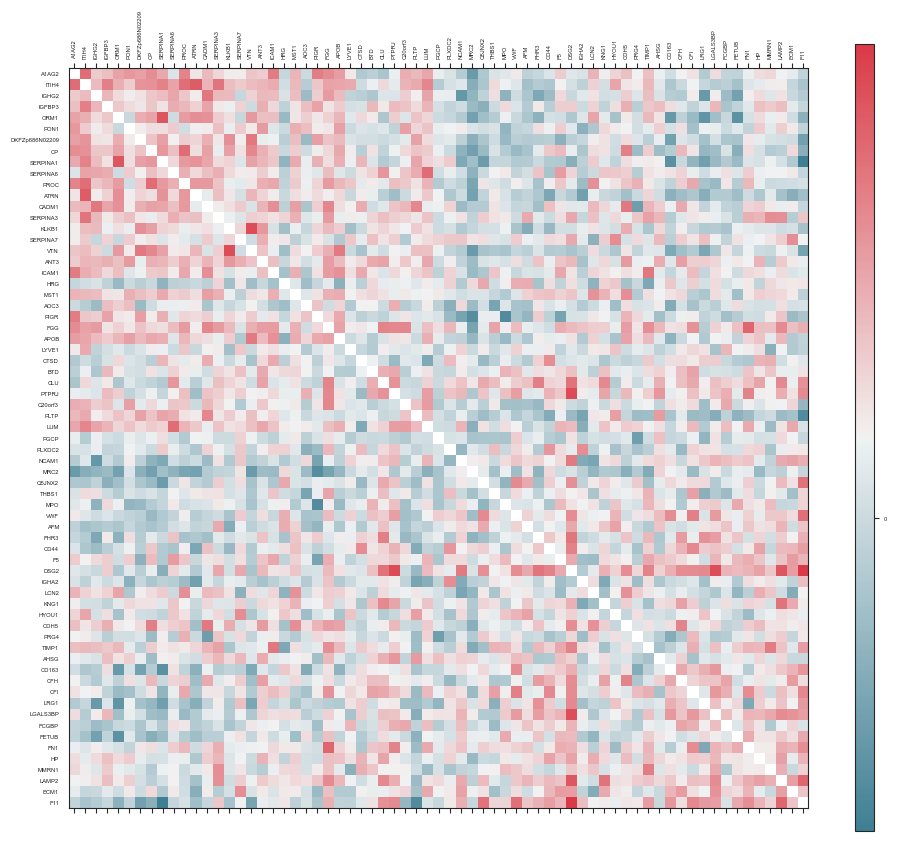

In [16]:
simtvae1 = simtvae1.reindex(columns, axis=1)
plot_corr(simtvae1,size=10)


#### Correlation for Copula CRC

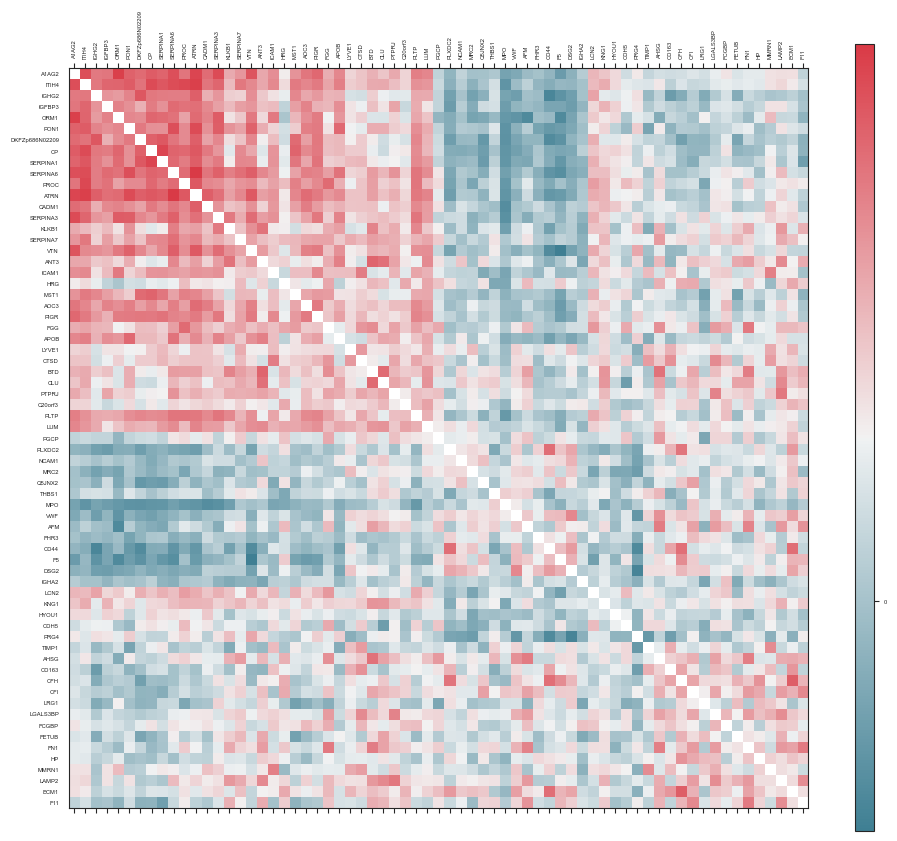

In [17]:
simco1 = simco1.reindex(columns, axis=1)
plot_corr(simco1,size=10)

#### Class Prediction

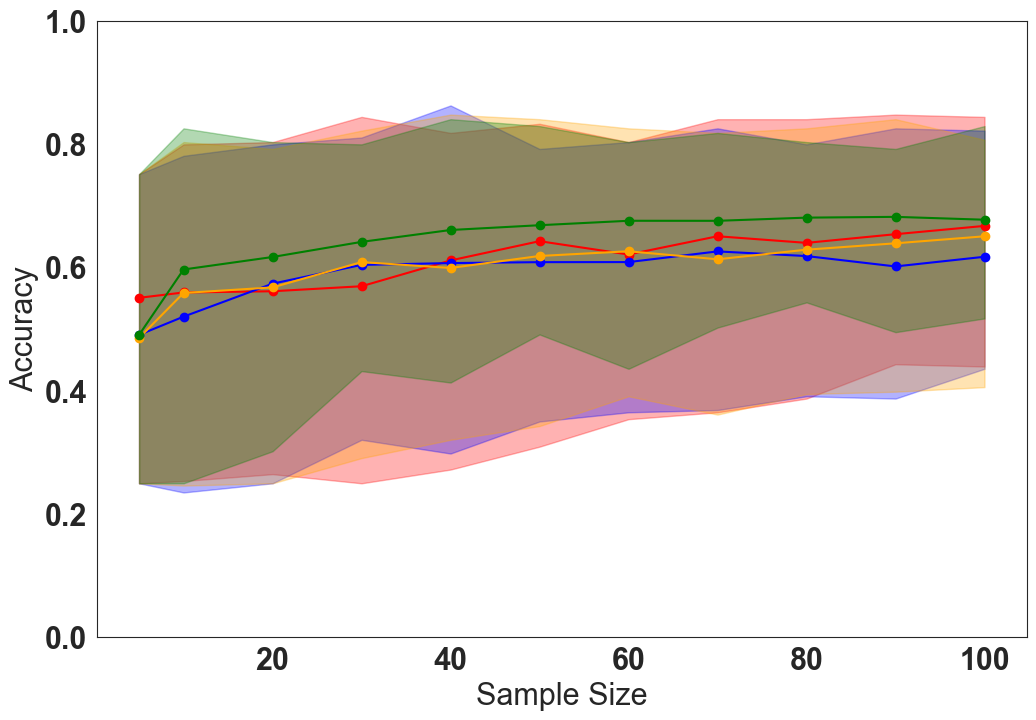

In [18]:
rfaccuracy = pd.read_csv('../casestudy/crc/crcrfaccuracynorm.csv')

crc_data_val = rfaccuracy
# Plotting
# matplotlib.rcParams.update({'font.size': 22})
font = {'weight' : 'bold',
        'size'   : 22}

matplotlib.rc('font', **font)

plt.figure(figsize=(12, 8))
# Plot REAL
plt.plot(crc_data_val['Sample Size'], crc_data_val['Accuracy'],label='Experimental',marker='o', color='red')
plt.fill_between(crc_data_val['Sample Size'], crc_data_val['min'], crc_data_val['max'], color='red', alpha=0.3)


# Plot PP
plt.plot(crc_data_val['Sample Size'], crc_data_val['PP Accuracy'], label='PP',marker='o', color='blue')
plt.fill_between(crc_data_val['Sample Size'], crc_data_val['PP min'], crc_data_val['PP max'], color='blue', alpha=0.3)

# Plot CO
plt.plot(crc_data_val['Sample Size'], crc_data_val['CO Accuracy'], label='CO',marker='o', color='orange')
plt.fill_between(crc_data_val['Sample Size'], crc_data_val['CO min'], crc_data_val['CO max'], color='orange', alpha=0.3)


# Plot TVAE
plt.plot(crc_data_val['Sample Size'], crc_data_val['TVAE Accuracy'], label='TVAE',marker='o', color='green')
plt.fill_between(crc_data_val['Sample Size'], crc_data_val['TVAE min'], crc_data_val['TVAE max'], color='green', alpha=0.3)

# Labels and legend
plt.xlabel('Sample Size')
plt.ylabel('Accuracy')
plt.ylim(0, 1) 

plt.show()


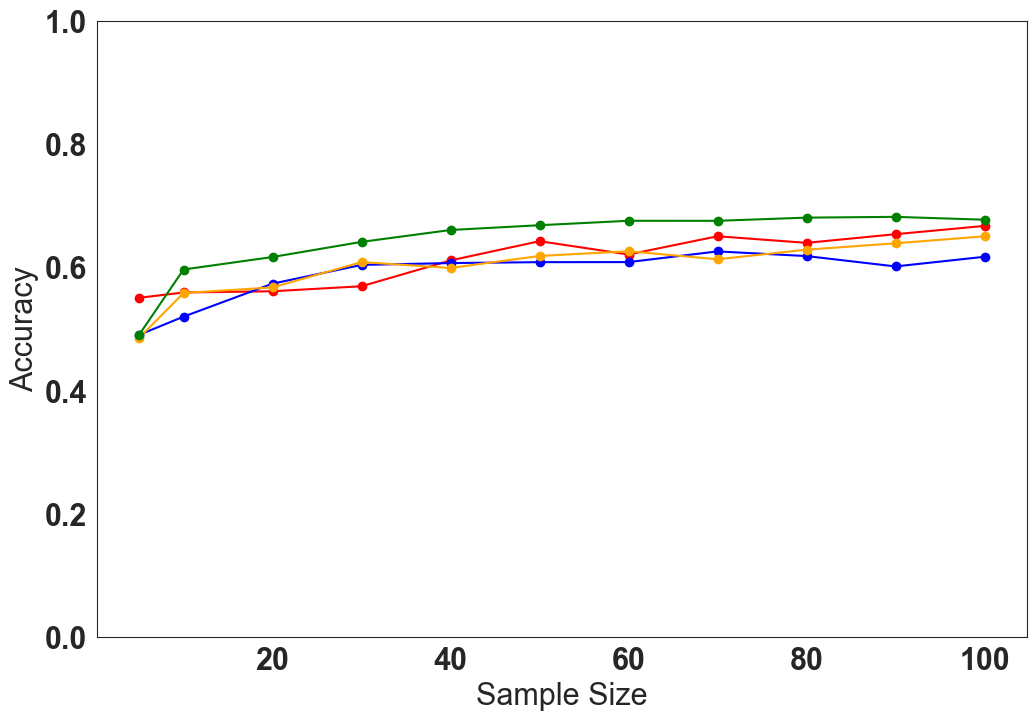

In [19]:
crc_data_val = rfaccuracy
# Plotting
# matplotlib.rcParams.update({'font.size': 22})
font = {'weight' : 'bold',
        'size'   : 22}

matplotlib.rc('font', **font)

plt.figure(figsize=(12, 8))
# Plot REAL
plt.plot(crc_data_val['Sample Size'], crc_data_val['Accuracy'],label='Experimental',marker='o', color='red')
# plt.fill_between(crc_data_val['Sample Size'], crc_data_val['min'], crc_data_val['max'], color='red', alpha=0.3)


# Plot PP
plt.plot(crc_data_val['Sample Size'], crc_data_val['PP Accuracy'], label='PP',marker='o', color='blue')
# plt.fill_between(crc_data_val['Sample Size'], crc_data_val['PP min'], crc_data_val['PP max'], color='blue', alpha=0.3)

# Plot CO
plt.plot(crc_data_val['Sample Size'], crc_data_val['CO Accuracy'], label='CO',marker='o', color='orange')
# plt.fill_between(crc_data_val['Sample Size'], crc_data_val['CO min'], crc_data_val['CO max'], color='orange', alpha=0.3)


# Plot TVAE
plt.plot(crc_data_val['Sample Size'], crc_data_val['TVAE Accuracy'], label='TVAE',marker='o', color='green')
# plt.fill_between(crc_data_val['Sample Size'], crc_data_val['TVAE min'], crc_data_val['TVAE max'], color='green', alpha=0.3)

# Labels and legend
plt.xlabel('Sample Size')
plt.ylabel('Accuracy')
# plt.title('Accuracy vs Sample Size for Different Methods')
# plt.legend()
# plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
# Show plot
# plt.grid(True)
plt.ylim(0, 1) 

plt.show()


##### Class Discovery

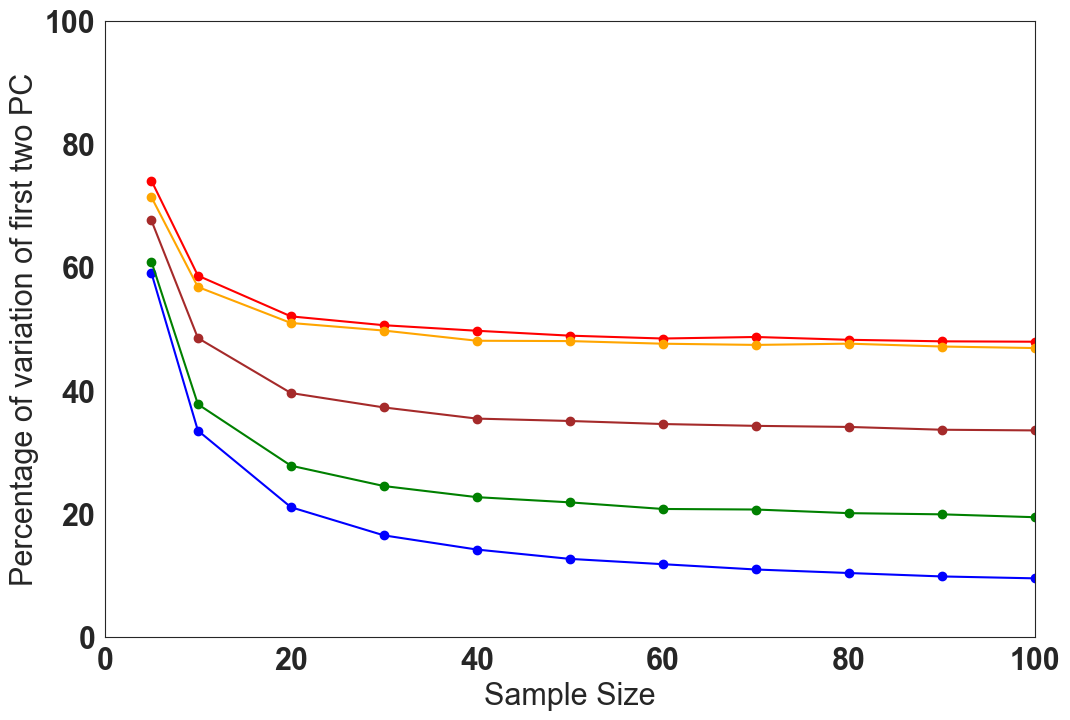

In [20]:
pcaaccuracy = pd.read_csv('../casestudy/crc/crcpca.csv')
crc_data_val = pcaaccuracy
# Plotting
# matplotlib.rcParams.update({'font.size': 22})
font = {'weight' : 'bold',
        'size'   : 22}

matplotlib.rc('font', **font)

plt.figure(figsize=(12, 8))
# Plot REAL
plt.plot(crc_data_val['Sample Size'], crc_data_val['Accuracy'],label='Experimental',marker='o', color='red')
# plt.fill_between(crc_data_val['Sample Size'], crc_data_val['min'], crc_data_val['max'], color='red', alpha=0.3)

plt.plot(crc_data_val['Sample Size'], crc_data_val['Accuracy v'],label='Experimental Validation',marker='o', color='brown')
# plt.fill_between(crc_data_val['Sample Size'], crc_data_val['min v'], crc_data_val['max v'], color='brown', alpha=0.3)


# Plot PP
plt.plot(crc_data_val['Sample Size'], crc_data_val['PP Accuracy'], label='PP',marker='o', color='blue')
# plt.fill_between(crc_data_val['Sample Size'], crc_data_val['PP min'], crc_data_val['PP max'], color='blue', alpha=0.3)

# Plot CO
plt.plot(crc_data_val['Sample Size'], crc_data_val['CO Accuracy'], label='CO',marker='o', color='orange')
# plt.fill_between(crc_data_val['Sample Size'], crc_data_val['CO min'], crc_data_val['CO max'], color='orange', alpha=0.3)


# Plot TVAE
plt.plot(crc_data_val['Sample Size'], crc_data_val['TVAE Accuracy'], label='TVAE',marker='o', color='green')
# plt.fill_between(crc_data_val['Sample Size'], crc_data_val['TVAE min'], crc_data_val['TVAE max'], color='green', alpha=0.3)

# Labels and legend
plt.xlabel('Sample Size')
plt.ylabel('Percentage of variation of first two PC')

plt.ylim(0, 100)
plt.xlim(0,100)
plt.show()


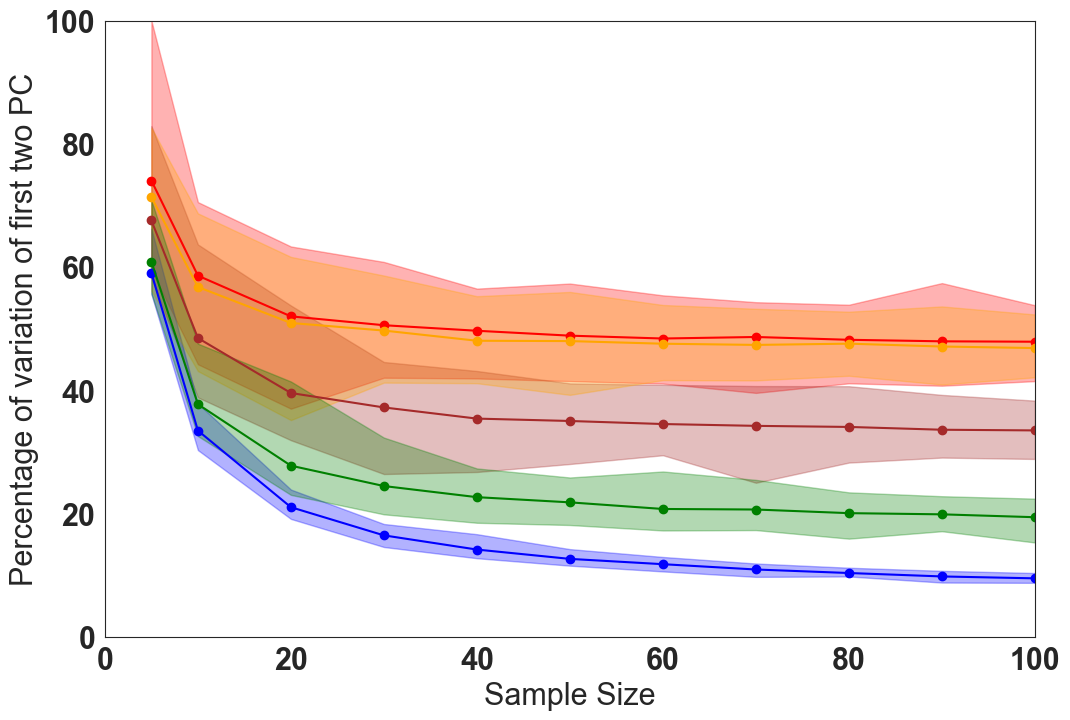

In [21]:
font = {'weight' : 'bold',
        'size'   : 22}

matplotlib.rc('font', **font)

plt.figure(figsize=(12, 8))
# Plot REAL
plt.plot(crc_data_val['Sample Size'], crc_data_val['Accuracy'],label='Experimental',marker='o', color='red')
plt.fill_between(crc_data_val['Sample Size'], crc_data_val['min'], crc_data_val['max'], color='red', alpha=0.3)

plt.plot(crc_data_val['Sample Size'], crc_data_val['Accuracy v'],label='Experimental Validation',marker='o', color='brown')
plt.fill_between(crc_data_val['Sample Size'], crc_data_val['min v'], crc_data_val['max v'], color='brown', alpha=0.3)


# Plot PP
plt.plot(crc_data_val['Sample Size'], crc_data_val['PP Accuracy'], label='PP',marker='o', color='blue')
plt.fill_between(crc_data_val['Sample Size'], crc_data_val['PP min'], crc_data_val['PP max'], color='blue', alpha=0.3)

# Plot CO
plt.plot(crc_data_val['Sample Size'], crc_data_val['CO Accuracy'], label='CO',marker='o', color='orange')
plt.fill_between(crc_data_val['Sample Size'], crc_data_val['CO min'], crc_data_val['CO max'], color='orange', alpha=0.3)


# Plot TVAE
plt.plot(crc_data_val['Sample Size'], crc_data_val['TVAE Accuracy'], label='TVAE',marker='o', color='green')
plt.fill_between(crc_data_val['Sample Size'], crc_data_val['TVAE min'], crc_data_val['TVAE max'], color='green', alpha=0.3)

# Labels and legend
plt.xlabel('Sample Size')
plt.ylabel('Percentage of variation of first two PC')

plt.ylim(0, 100)
plt.xlim(0,100)
plt.show()


##### Class Comparison

In [22]:
adjusted_p_values = {}
adjusted_p_values_pp = {}
adjusted_p_values_co = {}
adjusted_p_values_tvae = {}
dicts = {'real_adjust': adjusted_p_values, 'pp_adjust': adjusted_p_values_pp, 'co_adjust': adjusted_p_values_co, 'tvae_adjust': adjusted_p_values_tvae}  # Add more dictionaries as needed

# Load each JSON file and update the corresponding dictionary
for key, value in dicts.items():
    file_path = f'../casestudy/crc/pval/{key}.json'
    with open(file_path, 'r') as json_file:
        value.update(json.load(json_file))

sample_sizes=[5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100]

real = []
pp = []
co = []
tvae = []
realmin = []
realmax = []
ppmin = []
ppmax = []
comin = []
comax = []
tvaemin = []
tvaemax = []

col = 'CP'

for s in sample_sizes:
    s = str(s)
    real.append(np.median(adjusted_p_values[s][col]))
    pp.append(np.median(adjusted_p_values_pp[s][col]))
    co.append(np.median(adjusted_p_values_co[s][col]))
    tvae.append(np.median(adjusted_p_values_tvae[s][col]))
    realmin.append(np.min(adjusted_p_values[s][col]))
    realmax.append(np.max(adjusted_p_values[s][col]))
    ppmin.append(np.min(adjusted_p_values_pp[s][col]))
    ppmax.append(np.max(adjusted_p_values_pp[s][col]))
    comin.append(np.min(adjusted_p_values_co[s][col]))
    comax.append(np.max(adjusted_p_values_co[s][col])) 
    tvaemin.append(np.min(adjusted_p_values_tvae[s][col]))
    tvaemax.append(np.max(adjusted_p_values_tvae[s][col]))


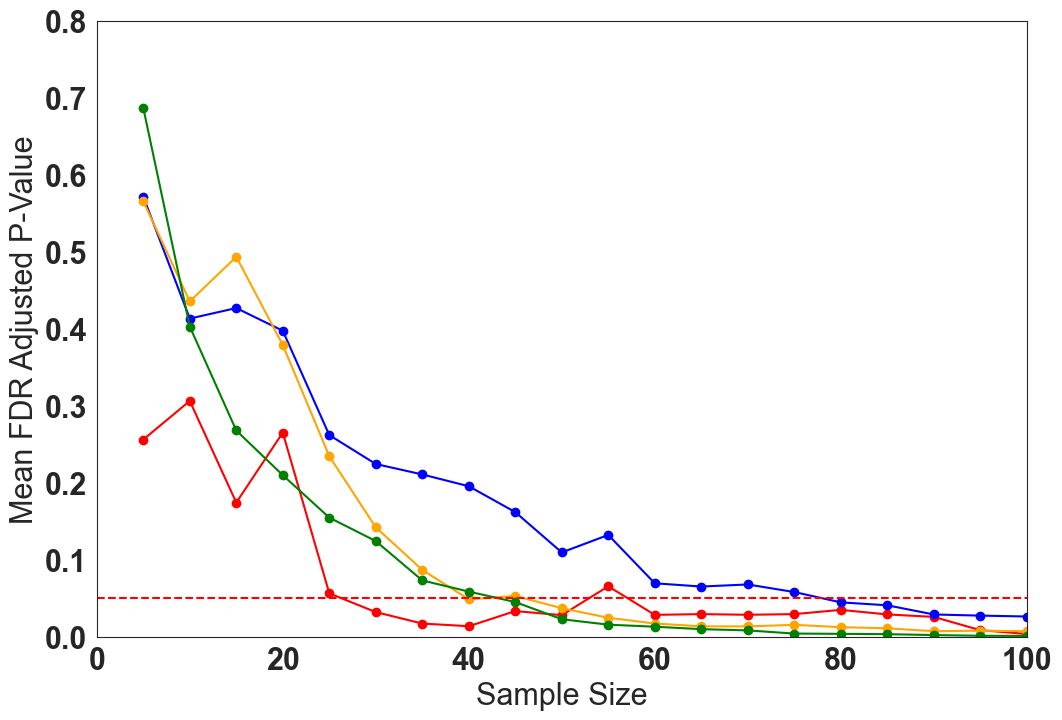

In [23]:
plt.figure(figsize=(12, 8))
font = {'weight' : 'bold',
        'size'   : 22}

matplotlib.rc('font', **font)
plt.plot(sample_sizes, real, marker='o', label='Experimental', color='red', linestyle='-')
# plt.fill_between(sample_sizes, realmin, realmax, color='red', alpha=0.3)

plt.plot(sample_sizes, pp, marker='o', label='Per-Protein', color='blue', linestyle='-')
# plt.fill_between(sample_sizes, ppmin, ppmax, color='blue', alpha=0.3)

plt.plot(sample_sizes, co, marker='o', label='Copula', color='orange', linestyle='-')
# plt.fill_between(sample_sizes, comin, comax, color='orange', alpha=0.3)

plt.plot(sample_sizes, tvae, marker='o', label='TVAE', color='green', linestyle='-')
# plt.fill_between(sample_sizes, tvaemin, tvaemax, color='green', alpha=0.3)

plt.axhline(y=0.05, color='red', linestyle='--')

plt.xlabel('Sample Size')
plt.ylabel('Mean FDR Adjusted P-Value')

plt.ylim(0.0,0.8)
plt.xlim(0,100)
plt.show()

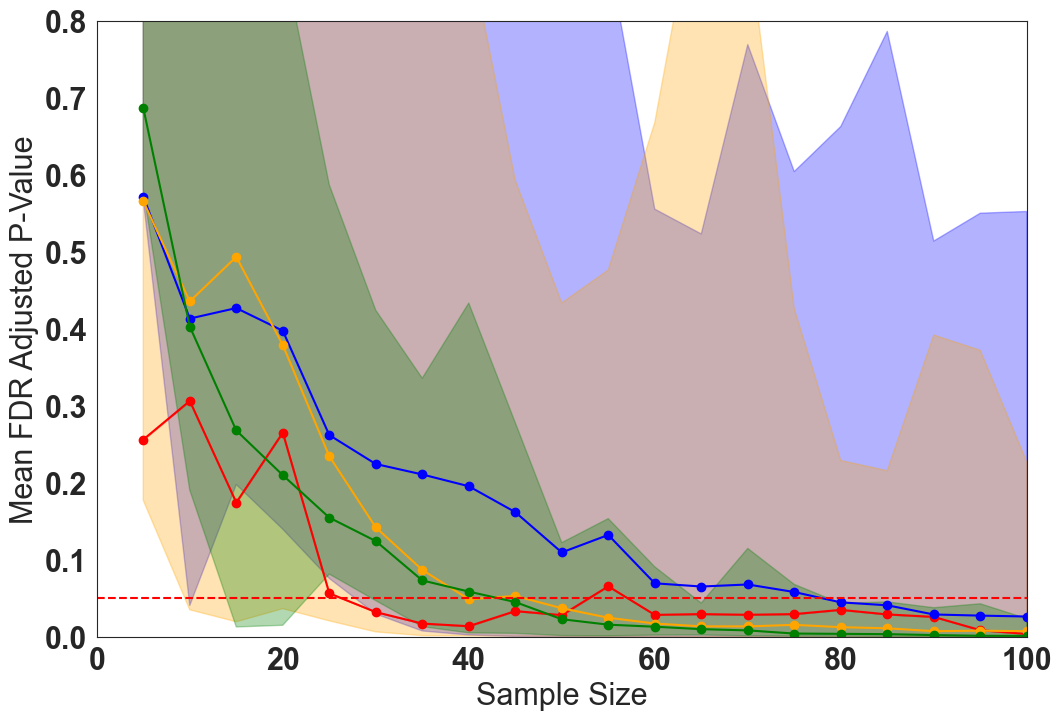

In [24]:
plt.figure(figsize=(12, 8))
font = {'weight' : 'bold',
        'size'   : 22}

matplotlib.rc('font', **font)
plt.plot(sample_sizes, real, marker='o', label='Experimental', color='red', linestyle='-')
plt.fill_between(sample_sizes, realmin, realmax, color='red', alpha=0.3)

plt.plot(sample_sizes, pp, marker='o', label='Per-Protein', color='blue', linestyle='-')
plt.fill_between(sample_sizes, ppmin, ppmax, color='blue', alpha=0.3)

plt.plot(sample_sizes, co, marker='o', label='Copula', color='orange', linestyle='-')
plt.fill_between(sample_sizes, comin, comax, color='orange', alpha=0.3)

plt.plot(sample_sizes, tvae, marker='o', label='TVAE', color='green', linestyle='-')
plt.fill_between(sample_sizes, tvaemin, tvaemax, color='green', alpha=0.3)

plt.axhline(y=0.05, color='red', linestyle='--')

plt.xlabel('Sample Size')
plt.ylabel('Mean FDR Adjusted P-Value')

plt.ylim(0.0,0.8)
plt.xlim(0,100)
plt.show()